# Purpose
The goal of this notebook is to demonstrate how to use Roman SNANA output files to make different types of plots. This notebook will recurrently be updated as new features are implemented.

This notebook uses [nested-pandas](https://github.com/lincc-frameworks/nested-pandas). Before getting started, you will need to [install nested-pandas](https://nested-pandas.readthedocs.io/en/latest/gettingstarted/installation.html#installation); additional documentation on nested-pandas can be found [here](https://nested-pandas.readthedocs.io/en/latest/).

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
from roman_snana_utils import nest_df, plot_lcs, plot_lc, days_between_obs

# Create a nested DataFrame object using Roman SNANA sims

In the cell below, specify the necessary parameters to create a nested DataFrame object. The notebook `access_roman_snana_sims.ipynb` explains what these parameters mean.

In [2]:
# specify parameters
index = "a00-t00-z00"
collection = "2TIER_RATE0"

fits_dump_dir = "fits_dump"
fits_dir = Path.cwd() / f"{fits_dump_dir}/{collection}/{index}"

# Ia model
phot_fits_filepath = f"{fits_dir}/ROMAN_SNIaMODEL0-0001_PHOT.FITS"
head_fits_filepath = f"{fits_dir}/ROMAN_SNIaMODEL0-0001_HEAD.FITS"

# non-Ia model
# phot_fits_filepath = f"{fits_dir}/ROMAN_NONIaMODEL1-0001_PHOT.FITS"
# head_fits_filepath = f"{fits_dir}/ROMAN_NONIaMODEL1-0001_HEAD.FITS"

In [3]:
nested_dataframe = nest_df(phot_fits_filepath, head_fits_filepath)
phot_data = nested_dataframe.iloc[0].PHOT_OBS # contains the photometric data for the first object in `nested_dataframe`

Explore the nested DataFrame object in the cells below:

In [4]:
nested_dataframe

,SNID,FAKE,RA,DEC,PIXSIZE,NXPIX,NYPIX,SNTYPE,NOBS,PTROBS_MIN,...,SIM_EXPOSURE_K,SIM_GALFRAC_R,SIM_GALFRAC_Z,SIM_GALFRAC_Y,SIM_GALFRAC_J,SIM_GALFRAC_H,SIM_GALFRAC_F,SIM_GALFRAC_K,SIM_SUBSAMPLE_INDEX,PHOT_OBS
0,105021,2,9.340802,-43.728172,0.11,-9,-9,110,53,1,...,1.0,6.936426e-01,3.515166e-01,0.512634,0.623376,3.720346e-14,4.030714e-14,4.826964e-14,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALER...
1,121992,2,9.743692,-44.089897,0.11,-9,-9,110,120,55,...,1.0,6.532125e-15,7.537994e-15,0.525929,0.669445,7.963458e-01,1.381791e+00,1.825865e-14,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALERR ...
2,103443,2,9.369211,-44.103979,0.11,-9,-9,110,78,176,...,1.0,8.160554e-13,1.601524e-12,7.938356,15.189107,3.102059e+01,4.797237e+01,4.908996e-12,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALERR ...
3,243253,2,9.174126,-44.231256,0.11,-9,-9,110,107,255,...,1.0,2.994578e-14,6.642638e-14,1.011755,1.614590,2.890411e+00,5.222725e+00,1.278947e-13,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALERR ...
4,244033,2,9.435274,-43.866327,0.11,-9,-9,110,185,363,...,1.0,1.478272e-15,1.472001e-15,0.209905,0.170578,2.207098e-01,2.216510e-01,4.061217e-15,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALERR ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4481,259956,2,9.804131,-44.188033,0.11,-9,-9,110,60,420380,...,1.0,1.983961e-15,1.137114e-01,0.126567,0.156766,5.425299e-15,5.459711e-15,6.430179e-15,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALER...
4482,54766,2,9.635788,-43.541287,0.11,-9,-9,110,66,420441,...,1.0,2.669178e-01,9.899911e-02,0.104019,0.119766,4.480395e-15,5.511146e-15,5.913988e-15,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALERR...
4483,62941,2,9.796699,-43.855861,0.11,-9,-9,110,62,420508,...,1.0,7.086170e-16,3.017957e-02,0.041825,0.055917,2.292541e-15,2.455832e-15,2.970332e-15,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALERR...
4484,51385,2,9.526972,-44.033700,0.11,-9,-9,110,32,420571,...,1.0,9.234252e-01,1.117900e+00,1.868769,3.411984,2.397347e-13,3.330070e-13,3.700748e-13,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALER...


In [5]:
phot_data

,BAND,CCDNUM,FIELD,FLUXCAL,FLUXCALERR,GAIN,MJD,PHOTFLAG,PHOTPROB,PSF_NEA,RDNOISE,SIM_MAGOBS,SKY_SIG,SKY_SIG_T,XPIX,YPIX,ZEROPT,ZEROPT_ERR
0,Z,-9,SHALLOW,-1.653215,2.077948,1.0,55613.0013,0,-9.0,8.50,12.87,30.567942,4.37,0.0,-9.0,-9.0,30.747999,0.001
1,Y,-9,SHALLOW,1.590046,2.155611,1.0,55613.0027,0,-9.0,9.55,12.87,30.566675,4.65,0.0,-9.0,-9.0,30.801001,0.001
2,J,-9,SHALLOW,-3.805007,2.124823,1.0,55613.0040,0,-9.0,9.79,12.77,30.568169,4.71,0.0,-9.0,-9.0,30.823000,0.001
3,R,-9,SHALLOW,4.520726,1.432827,1.0,55621.0000,0,-9.0,6.74,12.87,28.035816,4.37,0.0,-9.0,-9.0,31.063999,0.001
4,Z,-9,SHALLOW,3.941573,2.125036,1.0,55621.0013,0,-9.0,8.50,12.87,26.483200,4.37,0.0,-9.0,-9.0,30.747999,0.001
5,Y,-9,SHALLOW,-0.761096,2.137902,1.0,55621.0027,0,-9.0,9.55,12.87,26.532513,4.65,0.0,-9.0,-9.0,30.801001,0.001
6,J,-9,SHALLOW,3.633841,2.164521,1.0,55621.0040,0,-9.0,9.79,12.77,26.636686,4.71,0.0,-9.0,-9.0,30.823000,0.001
7,R,-9,SHALLOW,2.718267,1.409022,1.0,55629.0000,0,-9.0,6.74,12.87,26.648378,4.37,0.0,-9.0,-9.0,31.063999,0.001
8,Z,-9,SHALLOW,10.295150,2.198817,1.0,55629.0013,0,-9.0,8.50,12.87,25.245729,4.37,0.0,-9.0,-9.0,30.747999,0.001
9,Y,-9,SHALLOW,8.653968,2.232588,1.0,55629.0027,0,-9.0,9.55,12.87,25.317879,4.65,0.0,-9.0,-9.0,30.801001,0.001


In [6]:
list(nested_dataframe.keys())

['SNID',
 'FAKE',
 'RA',
 'DEC',
 'PIXSIZE',
 'NXPIX',
 'NYPIX',
 'SNTYPE',
 'NOBS',
 'PTROBS_MIN',
 'PTROBS_MAX',
 'MWEBV',
 'MWEBV_ERR',
 'REDSHIFT_HELIO',
 'REDSHIFT_HELIO_ERR',
 'REDSHIFT_FINAL',
 'REDSHIFT_FINAL_ERR',
 'MASK_REDSHIFT_SOURCE',
 'VPEC',
 'VPEC_ERR',
 'HOSTGAL_NMATCH',
 'HOSTGAL_NMATCH2',
 'HOSTGAL_OBJID',
 'HOSTGAL_FLAG',
 'HOSTGAL_PHOTOZ',
 'HOSTGAL_PHOTOZ_ERR',
 'HOSTGAL_SPECZ',
 'HOSTGAL_SPECZ_ERR',
 'HOSTGAL_RA',
 'HOSTGAL_DEC',
 'HOSTGAL_SNSEP',
 'HOSTGAL_DDLR',
 'HOSTGAL_CONFUSION',
 'HOSTGAL_LOGMASS',
 'HOSTGAL_LOGMASS_ERR',
 'HOSTGAL_LOGSFR',
 'HOSTGAL_LOGSFR_ERR',
 'HOSTGAL_LOGsSFR',
 'HOSTGAL_LOGsSFR_ERR',
 'HOSTGAL_COLOR',
 'HOSTGAL_COLOR_ERR',
 'HOSTGAL_ELLIPTICITY',
 'HOSTGAL_OBJID2',
 'HOSTGAL_SQRADIUS',
 'HOSTGAL_OBJID_UNIQUE',
 'HOSTGAL_MAG_R',
 'HOSTGAL_MAG_Z',
 'HOSTGAL_MAG_Y',
 'HOSTGAL_MAG_J',
 'HOSTGAL_MAG_H',
 'HOSTGAL_MAG_F',
 'HOSTGAL_MAG_K',
 'HOSTGAL_MAGERR_R',
 'HOSTGAL_MAGERR_Z',
 'HOSTGAL_MAGERR_Y',
 'HOSTGAL_MAGERR_J',
 'HOSTGAL_MAGERR_

# Plot light curves

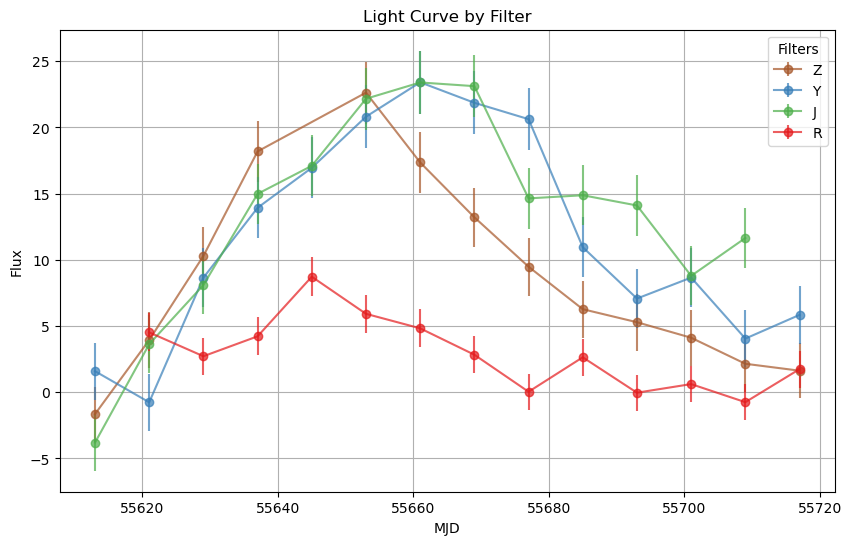

In [7]:
# create a plot with all of the available band data
plot_lcs(phot_data)

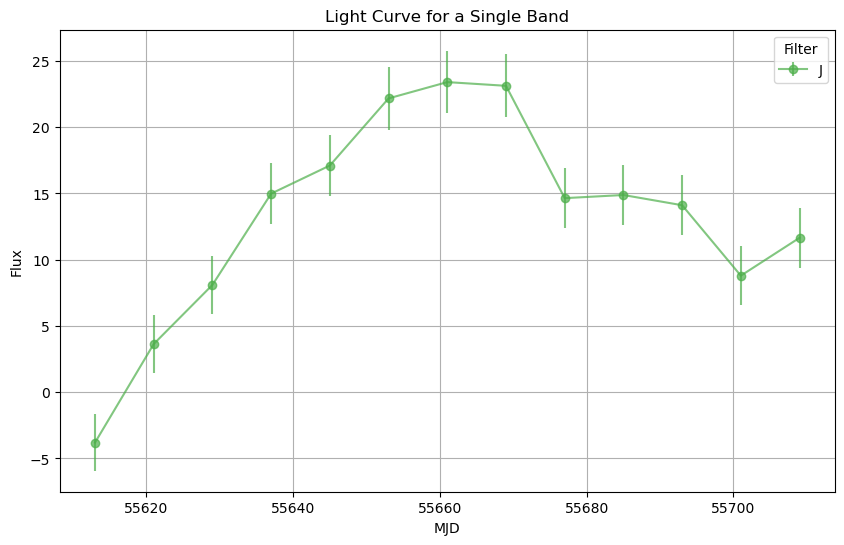

In [8]:
# create a plot using the data from a single band
plot_lc(phot_data, "J")

Alternatively, you can also plot light curves for a particular object by specifying it's SNID:

In [9]:
phot_snid_121992 = nested_dataframe[nested_dataframe["SNID"] == "121992"]
phot_snid_121992

,SNID,FAKE,RA,DEC,PIXSIZE,NXPIX,NYPIX,SNTYPE,NOBS,PTROBS_MIN,...,SIM_EXPOSURE_K,SIM_GALFRAC_R,SIM_GALFRAC_Z,SIM_GALFRAC_Y,SIM_GALFRAC_J,SIM_GALFRAC_H,SIM_GALFRAC_F,SIM_GALFRAC_K,SIM_SUBSAMPLE_INDEX,PHOT_OBS
1,121992,2,9.743692,-44.089897,0.11,-9,-9,110,120,55,...,1.0,6.532125e-15,7.537994e-15,0.525929,0.669445,0.796346,1.381791,1.825865e-14,-9,BAND CCDNUM FIELD FLUXCAL FLUXCALERR ...


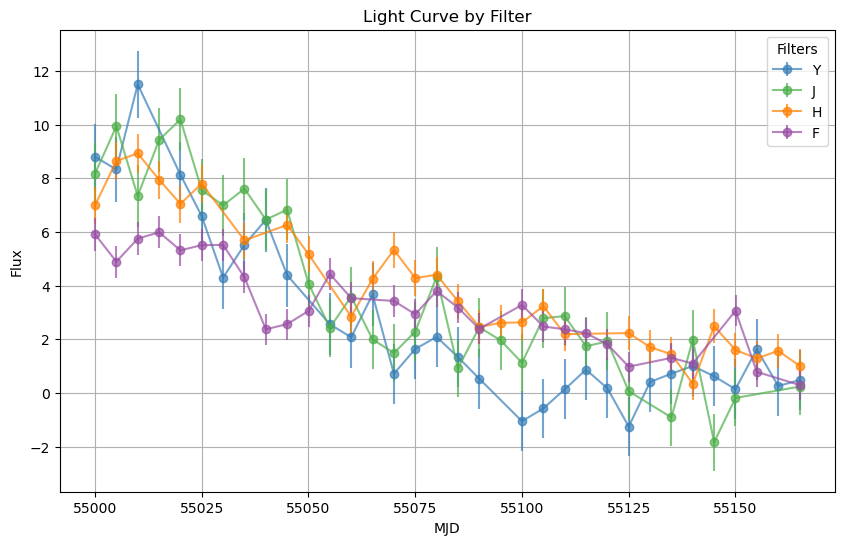

In [10]:
new_phot_data = phot_snid_121992.iloc[0].PHOT_OBS
plot_lcs(new_phot_data)

# Plot Histograms

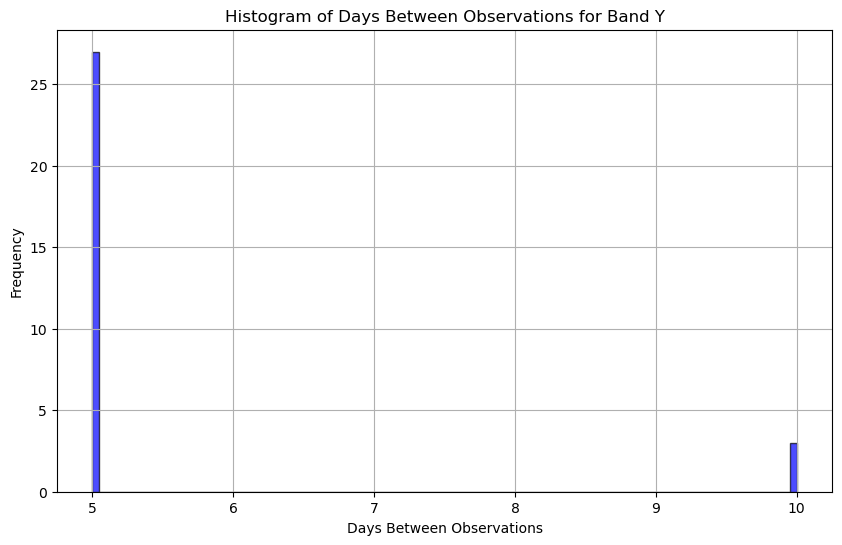

In [12]:
# plots histrogram of days between observerations for a specific band
days_between_obs(new_phot_data,'Y')

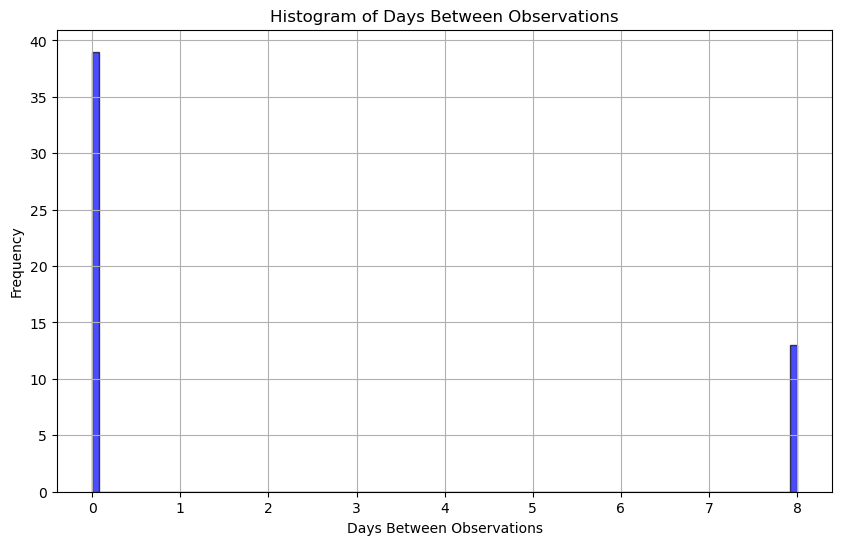

In [13]:
# plots histrogram of days between observerations for all bands
days_between_obs(new_phot_data)